In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


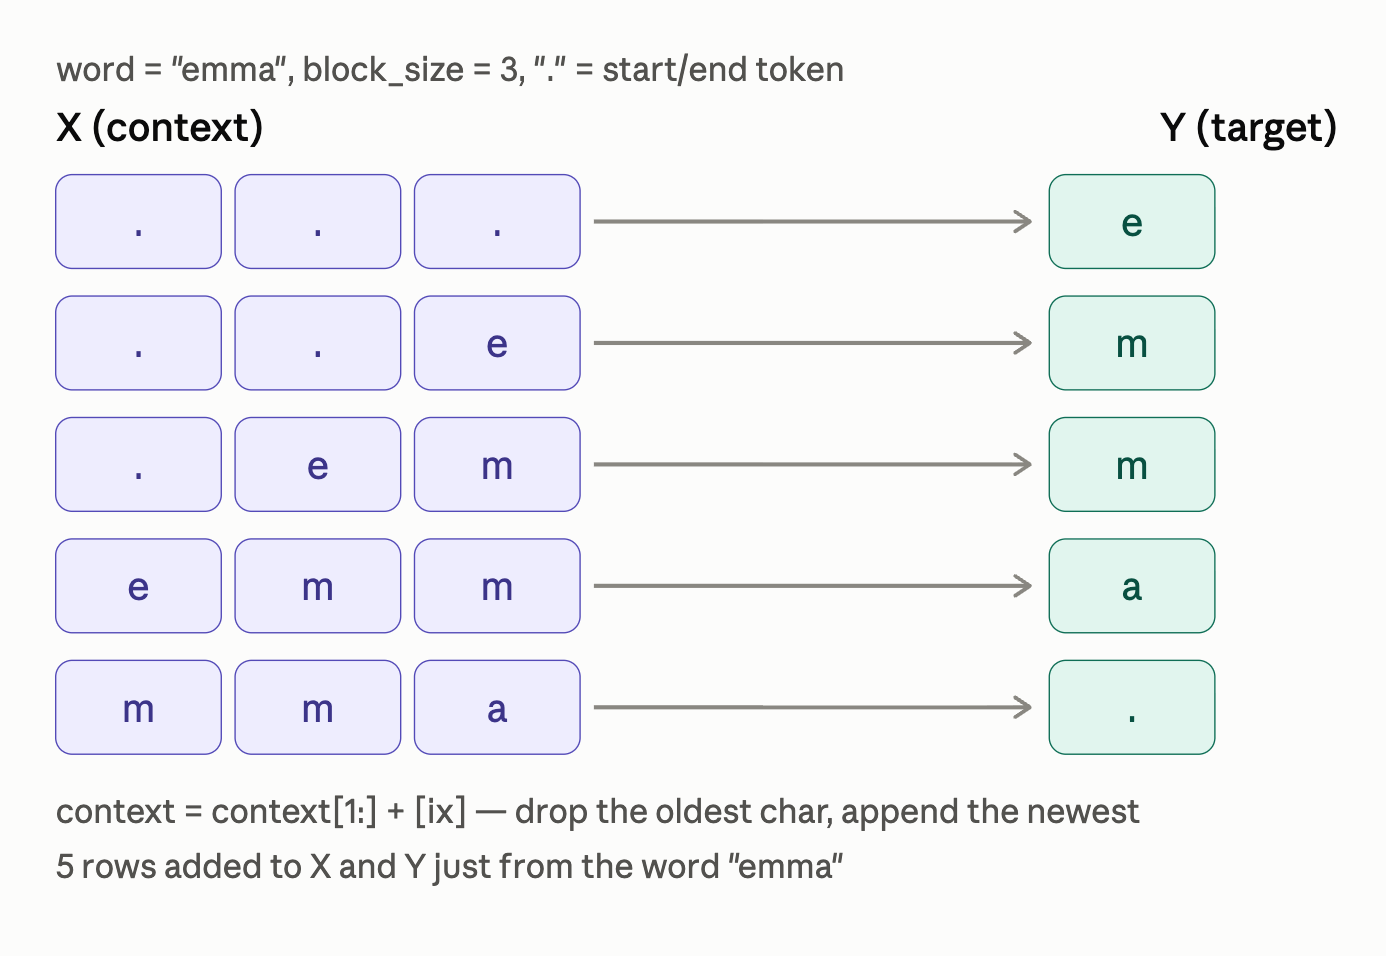

This is the dataset-building step for the MLP version of the character model — a major upgrade over the bigram approach, since instead of looking at just 1 previous character, it now looks at block_size previous characters as context.

Line by line

block_size = 3 — how many previous characters the model gets to see before predicting the next one. Where the bigram model only ever knew "the last 1 character," this model gets 3 characters of history — much richer context.

context = [0] * block_size — every word starts with a context of [0, 0, 0] — three copies of the padding token's index (., index 0), since there's no real history yet at the start of a word. This is the same start-token idea from your bigram diagrams, just repeated block_size times instead of once.

for ch in w + '.': — walks through every character of the word, plus one final . appended, so the model also learns when a word ends, same reasoning as before.

X.append(context) — records the current 3-character context as one training input.
Y.append(ix) — records the character that actually comes next, as the target for that context.

context = context[1:] + [ix] — this is the sliding window mechanism, and the key new mechanic here. context[1:] drops the oldest character (the first element), and + [ix] appends the character that was just predicted onto the end. This shifts the 3-character window forward by exactly one position each iteration — "crop and append," as the comment says.

Why this matters

With the bigram model, N[ix1, ix2] could only ever learn "given this 1 character, what comes next" — extremely limited context. This sliding window setup produces training examples where X has shape (num_examples, 3) — every row is 3 character indices — and Y has shape (num_examples,) — the single correct next character for each. This is exactly the input shape an MLP needs: a fixed-size numeric vector in, one prediction out. Feeding in 3 characters of context (rather than 1) lets the network learn much richer patterns, like "after 'th', an 'e' is very likely" — something a bigram model structurally cannot represent, since it never sees more than one character back.

build_dataset(words): same sliding-window logic, now packaged as a function

This is identical to the X/Y construction you looked at earlier (the emma sliding-context diagram) — it's just wrapped in a reusable function now, since you need to build this dataset structure three separate times, once for each data split. Same mechanics as before: pad with [0]*block_size, walk each character plus the end token ., record the current context into X and the next character into Y, then slide the window forward by dropping the oldest character and appending the new one. print(X.shape, Y.shape) just gives you a quick sanity check of how many training rows each split produced.

Why split the data into three groups at all

This is a standard machine learning practice, and it directly addresses something your earlier exercises didn't need to worry about: how do you know if your model has actually learned general patterns, versus just memorized the specific names it was trained on?

Xtr/Ytr (80%) — training set. This is the only data the model's weights are ever updated on — every loss.backward() and parameter update in your training loop uses only this data.
Xdev/Ydev (10%) — dev/validation set. The model never trains on this data directly, but you do use it repeatedly — to check the loss on names it hasn't memorized, and to decide things like hyperparameters (embedding size, hidden layer size, learning rate) by comparing how different choices perform here.
Xte/Yte (10%) — test set. Held back and checked only once, at the very end, after all tuning decisions are already locked in. This gives you an honest, unbiased final estimate of how well the model generalizes to genuinely unseen names — since if you kept tweaking things based on test set performance, you'd effectively be "training" on it indirectly, defeating its purpose as a truly held-out check.
Why shuffle before splitting

names.txt is stored in whatever order Karpathy's original file happened to list names — potentially not random (e.g., alphabetical, or by some other grouping). If you split words[:n1], words[n1:n2], words[n2:] without shuffling first, you'd risk each split containing systematically different kinds of names (e.g., all training names starting with early letters, all test names starting with late letters) — a biased split that could make your dev/test evaluation misleading.

random.shuffle(words) randomizes the order first, so each split ends up as a representative, random sample of the full dataset — not skewed by whatever incidental ordering existed in the original file.

Why random.seed(42) specifically

Same reproducibility concept as the torch.Generator().manual_seed(...) calls from earlier — without a fixed seed, random.shuffle would produce a different random order every time you ran the notebook, meaning your train/dev/test splits would differ from run to run. That would make it impossible to fairly compare two different training attempts (different hyperparameters, different architectures) — you wouldn't know if a change in dev loss came from your actual model change, or just from happening to get an easier/harder random split this time. Fixing the seed means every re-run produces the exact same 80/10/10 split, keeping comparisons fair and results reproducible.

In [7]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [8]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


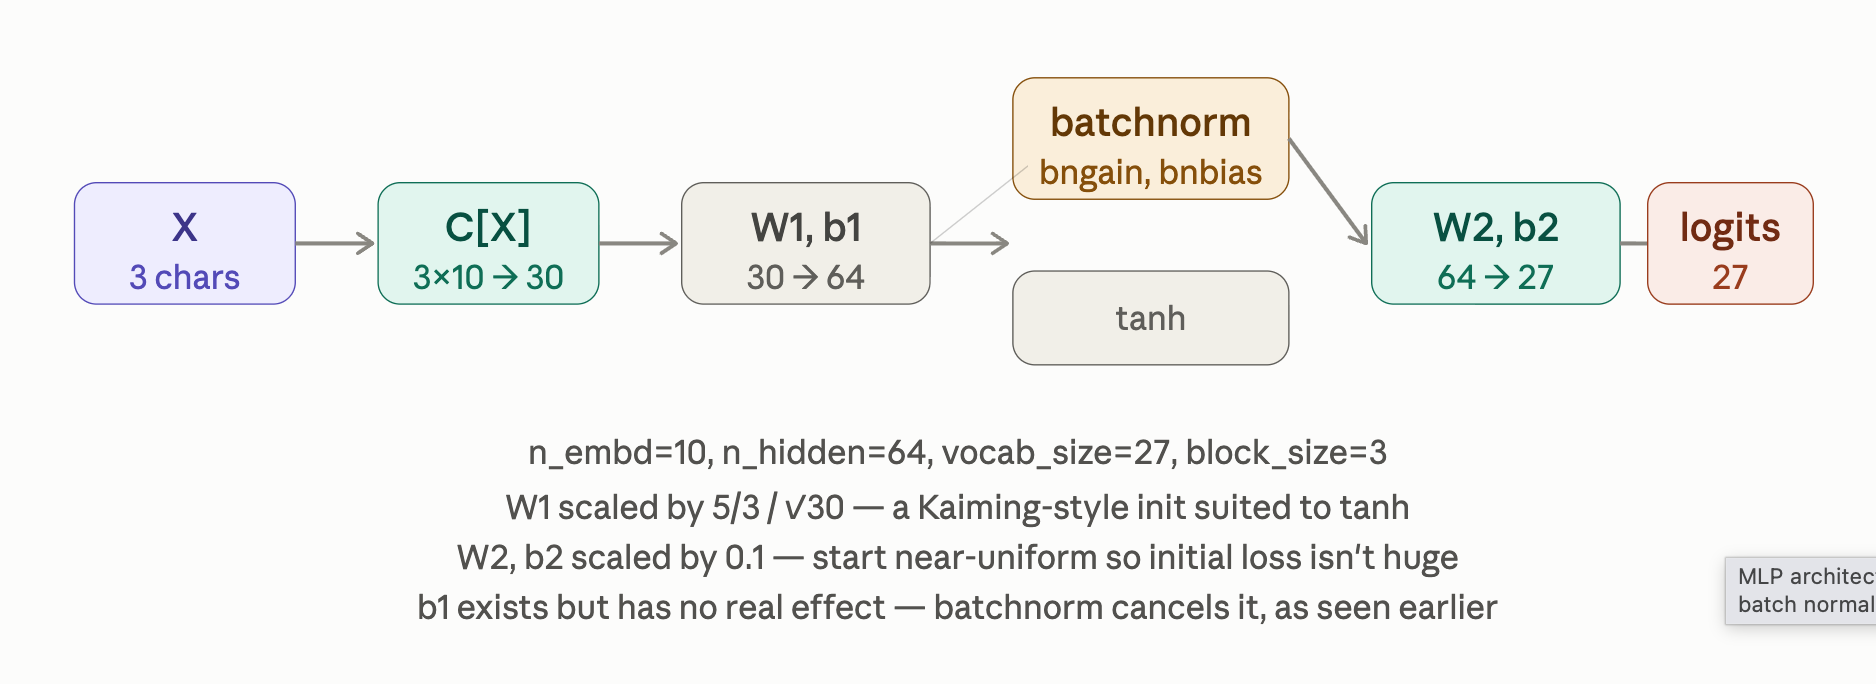

Full pipeline, matching your code

Input → embedding: C[X] looks up each of the 3 context characters in the (vocab_size, 10) embedding table (n_embd=10, so richer than the 2D toy example from earlier), then concatenation/flattening turns 3 separate 10-dimensional vectors into one 30-dimensional vector (n_embd * block_size = 10 * 3 = 30).

Linear layer 1: W1 has shape (30, 64), projecting the 30-dimensional embedding into n_hidden=64 hidden units. b1 is added too — but as you worked out a couple of questions back, it's immediately followed by batch normalization, which cancels its effect entirely. The comment # using b1 just for fun, it's useless because of BN is Karpathy explicitly acknowledging this — it's kept in only to show what happens, not because it matters.

Batch normalization: normalizes the pre-activation values using the batch's mean/std, then rescales with the learnable bngain (initialized near 1.0) and shifts with bnbias (initialized near 0.0) — these are the parameters that actually replace what b1 would have done, applied after normalization so they survive.

tanh: the nonlinearity, applied after batchnorm normalizes and rescales.

Linear layer 2: W2 has shape (64, 27), projecting the 64 hidden units down to vocab_size=27 — one raw score per possible next character.

Why the specific scaling factors matter

W1 * (5/3)/((n_embd*block_size)**0.5) — this is a deliberate weight initialization scheme (a Kaiming-style init tailored for tanh), designed to keep the spread of values flowing into tanh in a healthy range from the very first forward pass — not so large that tanh saturates (outputs stuck near -1/1, gradients near zero) and not so small that the network can barely produce varied outputs. The 5/3 gain factor is a commonly used constant specifically associated with tanh activations; dividing by √(fan_in) (here, √30) accounts for how many inputs get summed together — more inputs summed means naturally larger variance unless you compensate for it.

W2 * 0.1 and b2 * 0.1 — deliberately shrinking the output layer's initial weights keeps the initial logits close to uniform/small, which keeps the initial loss reasonable rather than wildly high. Karpathy covers this earlier in the series as a general lesson: bad initialization can create a huge, wasted first stretch of training just "fixing" an initially absurd loss, before any real learning happens.

Connecting to your earlier questions

This is the complete architecture underlying everything you've been debugging — the emb = C[X] lookup, the flattening step, the hpreact = embcat @ W1 (+ b1) pre-activation, the batchnorm coupling/jitter you asked about, and the cmp() gradient-checking utility are all pieces of exactly this pipeline, now assembled together with concrete dimensions.

In [9]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

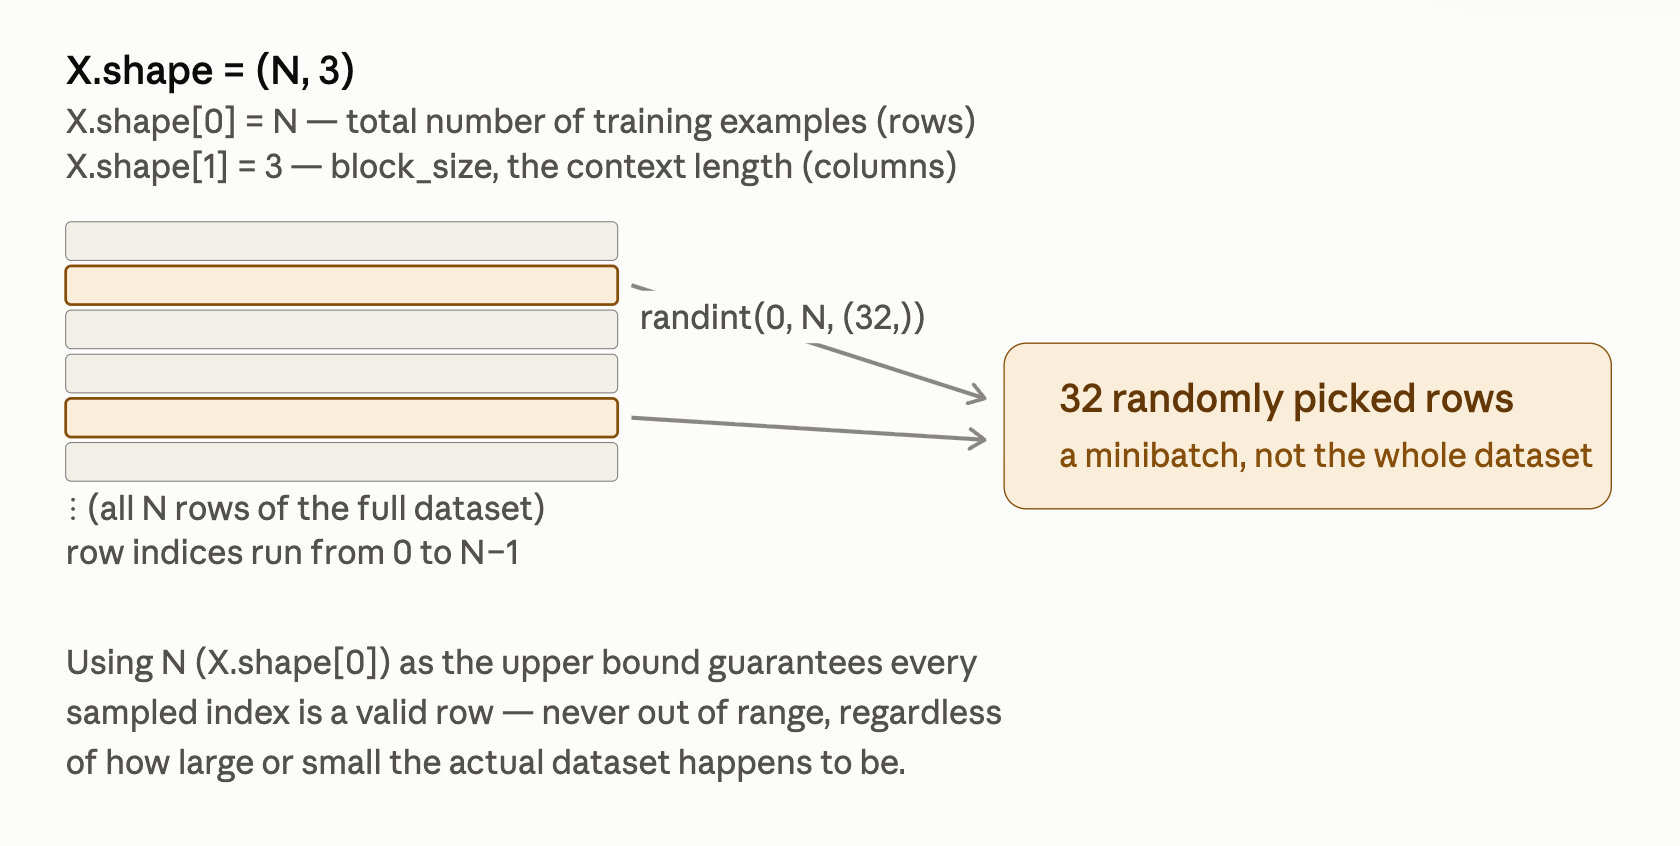

What X.shape[0] actually is

Recall X has shape (N, 3) — N rows (one per training example) and 3 columns (the context characters, from block_size=3). X.shape[0] pulls out the first dimension's size, which is N — the total number of training examples in your entire dataset (potentially tens of thousands, since it's built from every character transition across all 32,033 names).

Why it's needed as the upper bound in torch.randint
python
torch.randint(0, X.shape[0], (32,))

torch.randint(low, high, size) generates random integers in the range [low, high). Here, that means: generate 32 random integers, each somewhere between 0 and N-1. Each of these random integers is meant to be used as a row index into X and Y — i.e., "pick this specific training example."

The reason X.shape[0] specifically (not some fixed number like 1000) is critical: it guarantees every randomly generated index is a valid row in your actual dataset, no matter how large N actually is. If you hardcoded some arbitrary number as the upper bound instead, you'd risk either:

Too high → generating an index that's out of bounds, causing an IndexError when you try X[idx]
Too low → never sampling from large portions of your dataset at all, biasing training toward only the first chunk of examples
Why sample a minibatch at all, instead of using the whole dataset every step

This is the broader concept this line supports: instead of computing the loss and gradient over your entire dataset on every single training iteration (which is what your first working loop did, and is called full-batch gradient descent), this samples just 32 random rows each time — a minibatch. This makes each training step much faster (only 32 examples' worth of forward/backward computation, not tens of thousands), at the cost of each individual step being a noisier, less precise estimate of the true gradient. In practice, this trade-off is almost always worth it — you can take many more, faster steps in the same amount of time, which typically trains faster overall than fewer, slower, more "precise" full-batch steps.

In [10]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3519, grad_fn=<NegBackward0>)

In [ ]:
# loss is a mean: - (a + b + c) / 3 -> 
# dfx/da = -1/n; 
# the other logits do not feed into the loss (they don't contribute), this means that the derivative of the loss respect to them is zero
# this mean they are not considered in the derivative calculation as mean 1/n 

In [25]:
# Ex 1:
# sum(0/1, keepdim=True) in the forward pass -> replication/propagation in the backward pass along the same dimension
# replication/propagation in the forward pass -> variable re-use, sum(0/1, keepdim=True) in backward pass along the same dimension

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
dprobs = (1.0/probs) * dlogprobs # d(logx)/dx = 1/x * chain-rule; when probs low, gradient gets boosted
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True) #local derivative * chainrule; sum is needed bc of the propagation
dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
dcounts += torch.ones_like(counts) * dcounts_sum
dnorm_logits = counts * dcounts
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
dhpreact = (1.0 - h**2) * dh
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True)
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
dbndiff += (2*bndiff) * dbndiff2
dhprebn = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0)
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix = Xb[k,j]
    dC[ix] += demb[k,j]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

The underlying principle, once more

This is the exact same rule you first encountered in micrograd: whenever a value is used in more than one place in the computation graph, its true gradient is the sum of the gradient contributions from every place it was used — never just one of them in isolation. dcounts = counts_sum_inv * dprobs is correct as a first, partial step; it's only "the whole answer" once the second contribution from the counts_sum path is added on top of it a couple of lines later.

In [23]:
counts.shape, counts_sum_inv.shape, dprobs.shape

(torch.Size([32, 27]), torch.Size([32, 1]), torch.Size([32, 27]))

In [ ]:
# 2 ops: 1. propqgqtion of the veccotr counts_sum_inv and 2. multiplication

# C = A * B, but with tensors.
# A (3x3) and B(3x1) -->
# a11*b1 a12"b1 a13*b1
# a21*b2 a22*b2 a23*b2
# a31*b3 a32*b3 a33*b3
# C (3x3)

In [12]:
Yb # vector with indexes of correct predictions

tensor([ 8, 14, 15, 22,  0, 19,  9, 14,  5,  1, 20,  3,  8, 14, 12,  0, 11,  0,
        26,  9, 25,  0,  1,  1,  7, 18,  9,  3,  5,  9,  0, 18])

In [13]:
logprobs[range(n), Yb]

tensor([-4.0254, -3.1268, -3.5922, -3.2668, -4.1407, -3.4687, -3.1704, -3.9780,
        -3.1134, -4.3141, -3.1439, -1.6673, -2.9030, -3.0366, -2.9399, -3.1863,
        -3.8321, -3.0037, -3.6540, -3.4267, -2.8509, -3.0234, -4.3439, -4.0959,
        -3.4290, -2.9076, -3.0465, -3.9437, -2.6736, -3.4855, -3.3427, -3.1278],
       grad_fn=<IndexBackward0>)

In [17]:
logprobs[range(n), Yb].shape

torch.Size([32])

In [16]:
logprobs.shape

torch.Size([32, 27])

In [14]:
logprobs

tensor([[-2.7437, -2.4536, -3.9446, -3.0180, -3.9591, -2.4556, -3.7115, -3.3016,
         -4.0254, -3.5170, -3.2728, -3.3247, -3.2098, -3.5857, -3.3439, -4.2640,
         -4.7213, -4.0079, -4.1190, -2.8447, -3.0167, -3.8336, -3.6833, -2.6288,
         -2.8104, -3.6463, -3.8753],
        [-2.9860, -2.9494, -2.2449, -2.9707, -3.2862, -3.3445, -4.0329, -3.0545,
         -4.0606, -3.7509, -2.9818, -3.1027, -2.9806, -3.5224, -3.1268, -3.2713,
         -3.6798, -4.2243, -3.9302, -3.2159, -3.8999, -3.7976, -4.1323, -2.7571,
         -3.7605, -3.3279, -3.7736],
        [-3.9521, -3.7611, -4.0813, -4.3664, -3.7549, -3.1524, -2.7820, -2.7609,
         -2.8747, -3.5187, -3.8591, -3.3367, -3.0553, -3.0383, -3.7310, -3.5922,
         -4.2276, -3.4716, -3.5701, -2.2242, -2.7253, -3.3725, -3.2045, -3.2060,
         -3.2626, -3.9381, -3.6223],
        [-3.5420, -3.7454, -2.9912, -2.9799, -2.7876, -3.5568, -3.0522, -3.1753,
         -3.1060, -4.0507, -3.2731, -3.6633, -3.2773, -3.1404, -2.7974, -2.7167

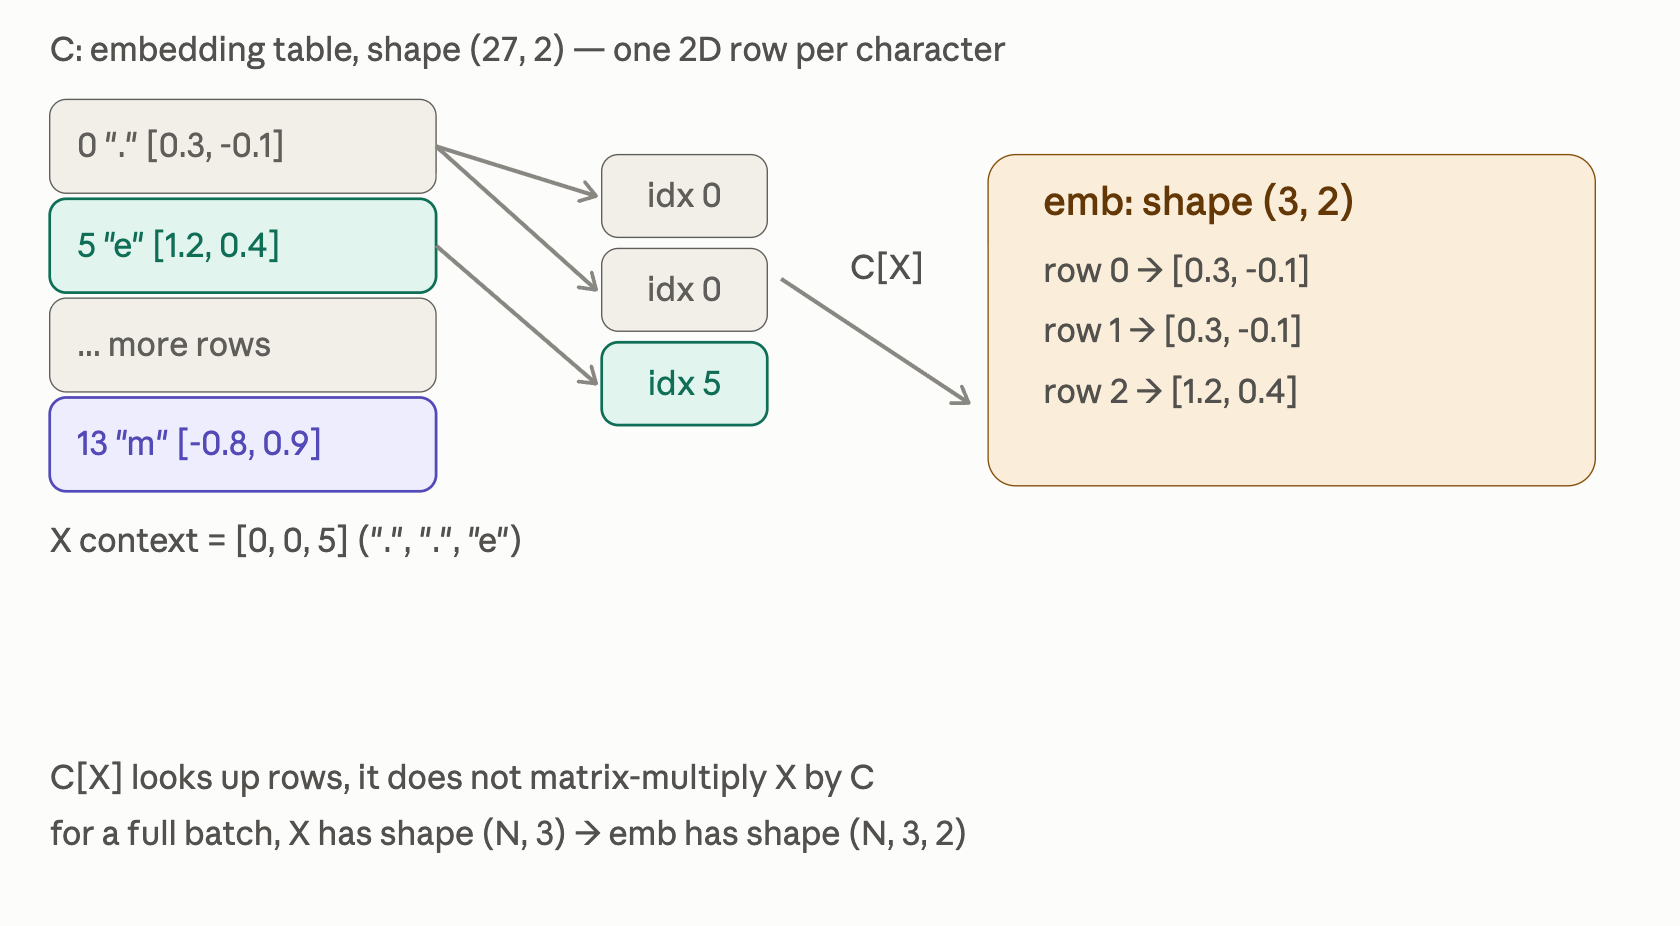

Correcting the operation: it's C[X], not X * C

C is the embedding table — a tensor of shape (27, 2), one row per character in your vocabulary, and each row is that character's 2-dimensional embedding vector (the very same 2D coordinates you'd later plot to visualize character clustering).

X holds integer indices, not floating-point data meant for multiplication. For one training example with block_size=3, X might be [0, 0, 5] — three character indices representing the context ., ., e.

C[X] uses PyTorch's fancy indexing: for each index in X, it pulls out the matching row from C. This is a lookup operation, conceptually identical to writing [C[0], C[0], C[5]] — just done efficiently and all at once via tensor indexing syntax, rather than an actual matrix multiplication (@ or * would be mathematically meaningless here, since X contains indices, not vectors to multiply against).

Why lookup, not multiplication

This is the same underlying idea as F.one_hot(...) @ W from your earlier bigram-neural-network code — but C[X] is a much more direct and efficient way to achieve the same result as one-hot-encoding followed by matrix multiplication. Mathematically, one_hot(ix) @ C and C[ix] produce identical output (both select row ix of C), but C[X] skips the wasteful step of constructing a giant mostly-zero one-hot vector just to multiply it out — it goes straight to indexing.

What the shapes look like at scale

For a single example, X has shape (3,) and emb = C[X] has shape (3, 2) — one 2D embedding vector per context character, stacked. For a full batch of N training examples, X has shape (N, 3), and emb = C[X] has shape (N, 3, 2) — PyTorch's indexing automatically broadcasts across the batch dimension, looking up the right row of C for every single index in the entire X tensor in one operation.

Where this feeds next

This emb tensor is the raw material for the next step in the MLP: it typically gets reshaped/flattened from (N, 3, 2) into (N, 6) — concatenating the 3 separate 2D embeddings into one 6-dimensional input vector per example — before being fed through a weight matrix into the hidden layer, similar in spirit to the xenc @ W pattern from your bigram neural net, just with a richer, learned representation of each character instead of a raw one-hot vector.

-
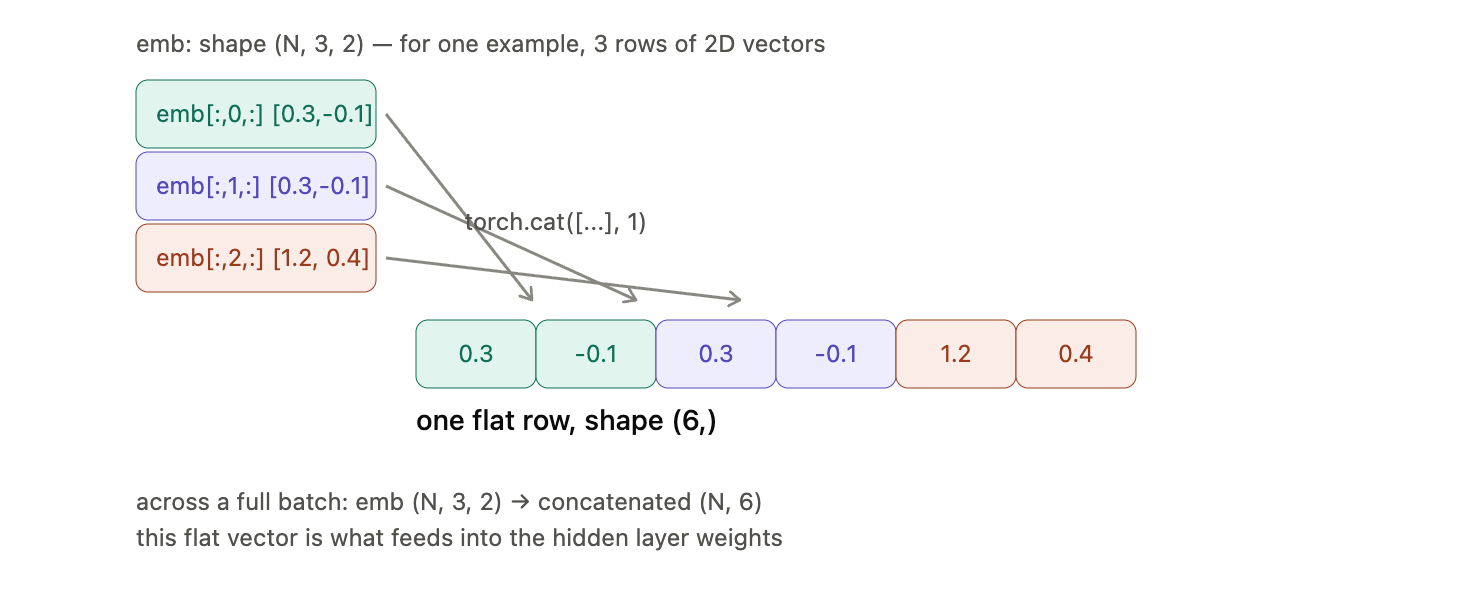

This line flattens the 3 separate context embeddings into one single row per example — turning the 3D tensor emb into a 2D tensor ready for a standard matrix multiplication.

Why this is needed

Recall emb = C[X] has shape (N, 3, 2): for every training example, you have 3 separate 2D embedding vectors — one per context character position. But a hidden layer's weight matrix expects a plain 2D input: (N, features), where each row is one flat vector of numbers. A 3D tensor doesn't fit that shape directly — you can't matrix-multiply (N, 3, 2) against a weight matrix the way you'd multiply (N, 6).

---
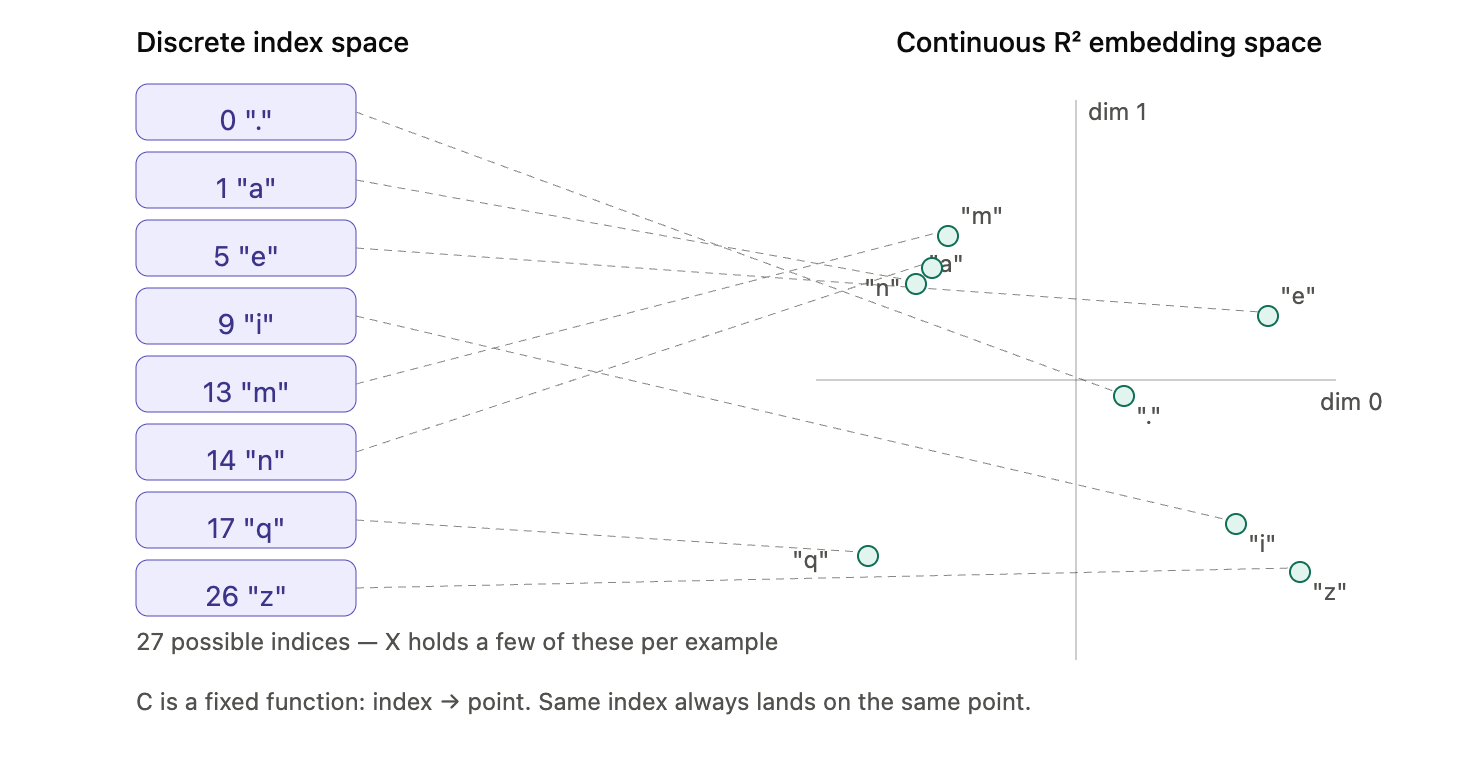

The mapping perspective: C as a function

Think of C not as "a table you index into," but as an actual function:


$$C: \{0, 1, 2, \dots, 26\} \rightarrow \mathbb{R}^2$$

Its domain is the 27 possible discrete character indices; its codomain is the entire continuous 2D plane. C[X] is just function application — evaluating C at each index found in X. This is the exact same idea as evaluating f(3) for some mathematical function f — except here f's "formula" isn't an equation, it's a lookup table of learned coordinates, one per possible input.

Why this reframing matters

Before training, C starts as a random function — every character gets initialized to a random point in 2D space, with no meaningful structure. Character a might randomly land near q, e might land far from every other vowel — total noise.

Training reshapes the function itself. Every time loss.backward() runs, gradients flow back through the embedding lookup and adjust C's rows directly — meaning training doesn't just tune the MLP's weights, it also moves the points in this 2D space. Over many iterations, C gradually reorganizes itself so that characters behaving similarly in the training data (e.g., vowels, which tend to appear in similar contexts across many names) drift toward each other, while characters behaving very differently drift apart.

What "same index → same point, always" means

A crucial property: C is deterministic and shared — every single occurrence of the character e anywhere in your entire dataset, across every training example, gets mapped to the exact same 2D point (C[5], assuming e is index 5). There's no "context-dependent" variation at this stage — this is a static embedding, one fixed vector per symbol, regardless of what came before or after it in any particular word. (This is worth noting because later, far more advanced architectures — like transformers — introduce contextual embeddings, where the same character/word can map to different vectors depending on surrounding context. This static embedding is the simpler starting point.)

Connecting to your earlier questions

This is exactly why Karpathy's paper comparison made sense: whether the domain is 27 characters or 17,000 words, C is the same kind of object — a learned function from a discrete vocabulary into a continuous space, sized appropriately for how much variety that vocabulary needs to represent. And it's why the concatenation step (torch.cat / .view()) comes right after: once you have 3 separate points in this space (one per context character), you flatten them into a single 6-dimensional vector so the next layer can process "where all three context characters currently sit in embedding space," together, as one combined signal for predicting the next character.

and the key insight is that concatenation is a fundamentally different operation from combining vectors within the same space (like adding or averaging them). Let's separate these two ideas clearly.

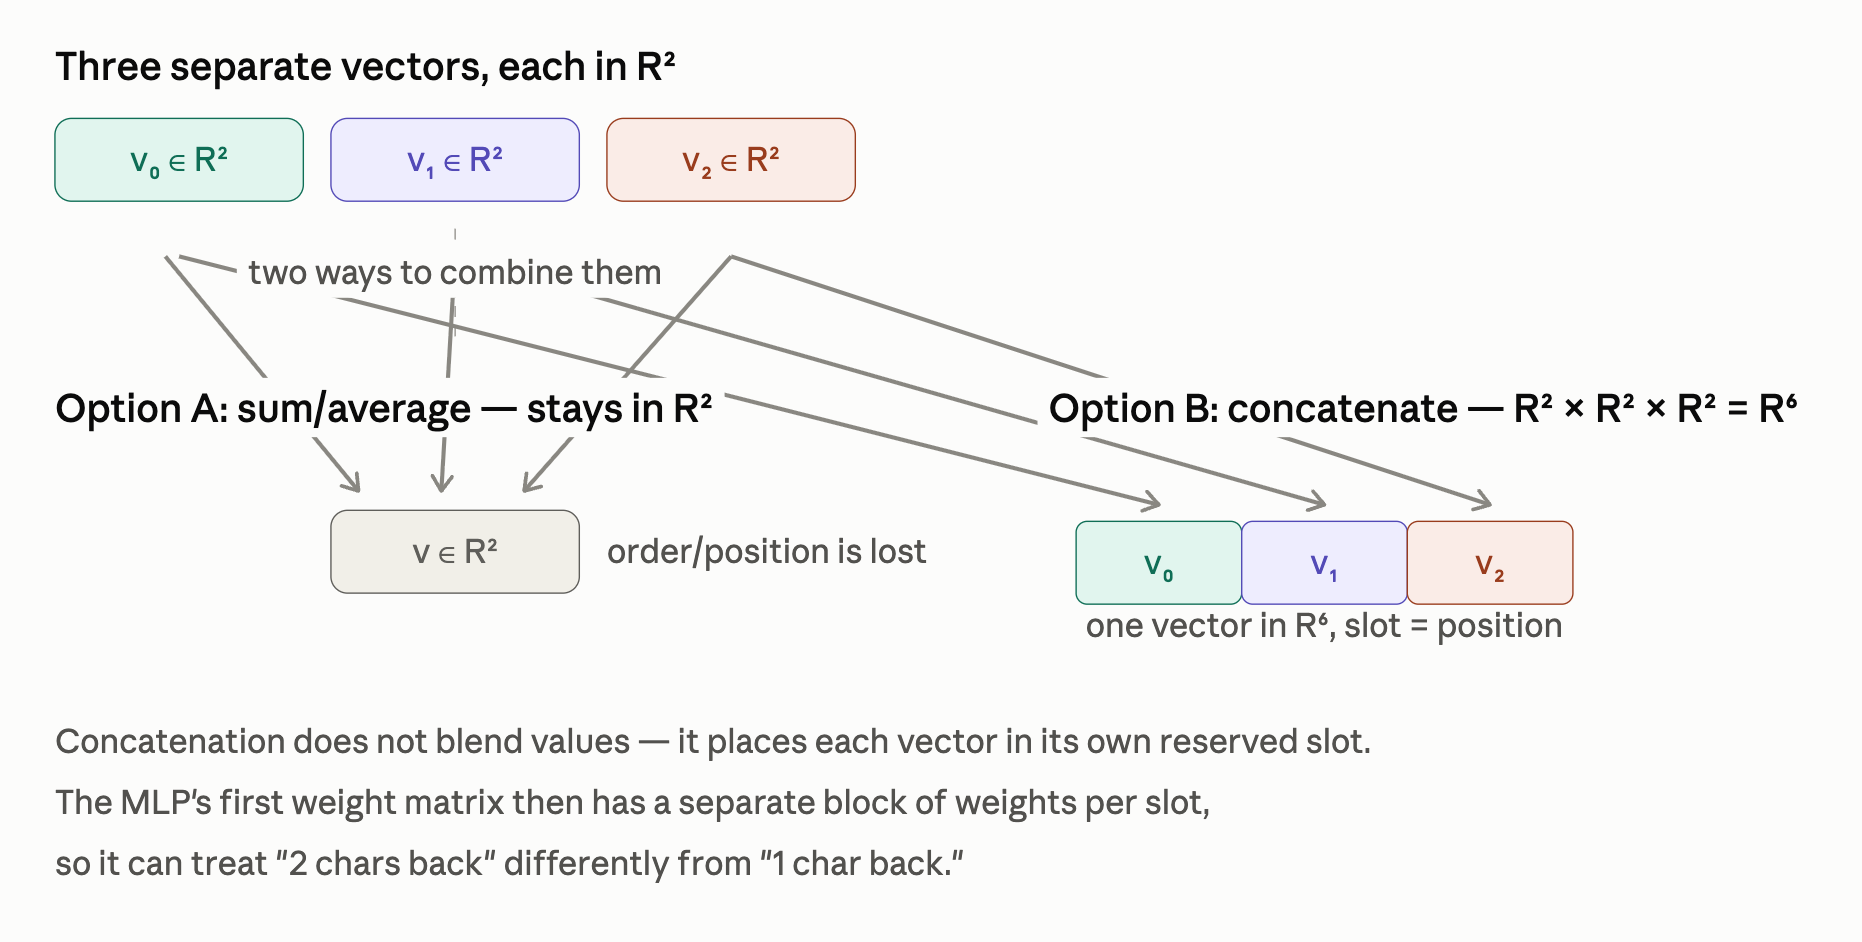

Two genuinely different ways to "combine" vectors

Your intuition to ask this is exactly right — there are two very different mathematical operations that both sound like "combining," and it matters a lot which one is happening.

Option A — combine within the same space (e.g., sum or average). If you added the three 2D vectors together (v0 + v1 + v2), you'd still land in R² — a single point in the same 2D embedding space. But this destroys information about position: you'd get the same result whether the context was "e, m, m" or "m, e, m" — the model would have no way to tell which character came first, second, or third. Order would be lost entirely.

Option B — concatenation, which is what actually happens. This isn't combining vectors within R² at all — it constructs a vector in an entirely different, larger space: the Cartesian/direct product R² × R² × R² = R⁶. Formally, if v0, v1, v2 ∈ R², concatenation produces (v0, v1, v2) ∈ R⁶ — a single 6-dimensional vector where the first 2 coordinates are v0, the next 2 are v1, and the last 2 are v2, untouched and unblended.

Why "product space," not "shared space"

This is the key conceptual distinction you're asking about: concatenation doesn't project all three vectors into one common space and merge them — it reserves a separate slot for each one, side by side, inside a bigger space. Nothing about v0's values changes when v1 and v2 join it; they're just sitting next to each other in a longer coordinate list. The "6" in R⁶ comes purely from 2 + 2 + 2 — three independent 2D spaces glued together positionally, not merged mathematically.

Why this specific choice (concatenation) is what the MLP needs

Because each 2D block occupies a fixed, known position in the 6D vector, the very next step — multiplying by the hidden layer's weight matrix — can learn completely different weights for each context position. The weights connected to coordinates 0-1 (the oldest context character) can behave entirely differently from the weights connected to coordinates 4-5 (the most recent context character). This lets the network learn things like "the character two positions back matters differently than the character right before the one I'm predicting." If you'd summed or averaged the vectors instead, that positional distinction would be structurally impossible to recover — the network would be blind to where in the context each character sat, only what values existed somewhere in that 3-character window.

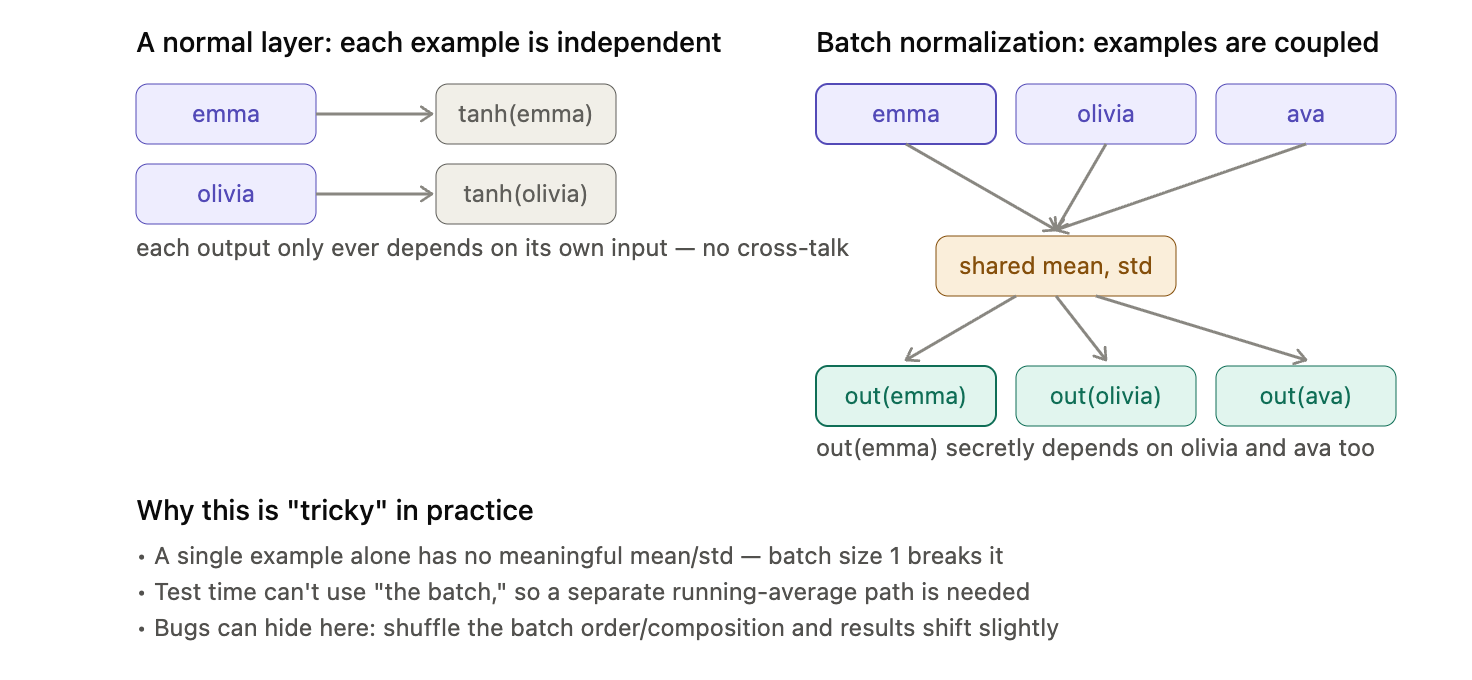

The unusual thing Karpathy is pointing to

Every other layer you've built so far — the linear layer (@ W1), tanh, even the embedding lookup — processes each example in a batch completely independently. Whatever happens to emma in the forward pass has zero effect on what happens to olivia, even though they're sitting in the same batch tensor. You could literally split a batch of 32 examples into 32 separate forward passes, one at a time, and get the identical result as running them together.

Batch normalization breaks that assumption entirely. Because it computes mean and std from the batch itself, every single example's output secretly depends on every other example that happened to be in the same batch. emma's normalized activation is different depending on whether olivia and ava are its batch-mates versus zoe and kai — exactly the jitter effect from earlier. This is a genuinely strange departure from how neural network layers normally behave, which is why Karpathy singles it out as the "tricky" part, not just a minor implementation detail.

Why this coupling causes real practical headaches

1. A single example has no valid statistics. If you tried to run just one example through a batchnorm layer by itself (batch size of 1), the "standard deviation" of a single number is either 0 or undefined — there's no meaningful spread to normalize against. This means batchnorm structurally requires multiple examples together to function at all, unlike every other layer.

2. Inference/test time needs an entirely separate mechanism. When you're actually using the trained model to generate a name (like your sampling loop), you're typically processing one example at a time — there's no "batch" to compute statistics from. This is why training must track a running average of mean/std across all the batches it's seen, so that at test time, the model uses those saved running statistics instead of trying (and failing) to compute fresh ones from a single input.

3. Results become sensitive to batch composition, not just content. Two completely correct implementations could produce slightly different results purely because they happened to group examples into different batches, or process them in a different order/shuffle. This makes debugging harder — an unexpected result might stem from which examples got batched together, not from an actual bug in your logic — a class of subtlety that simply doesn't exist in ordinary, per-example layers.

Why Karpathy flags this specifically

This coupling is exactly why batch normalization, despite working remarkably well in practice, has a reputation for being finicky to implement and reason about correctly — historically a common source of subtle bugs in real training pipelines (mismatched train/eval statistics, batch-size-dependent behavior, issues when using very small batches). Understanding why it's coupled — because it deliberately borrows statistics across examples, unlike anything else in the network — is what makes those failure modes predictable rather than mysterious.

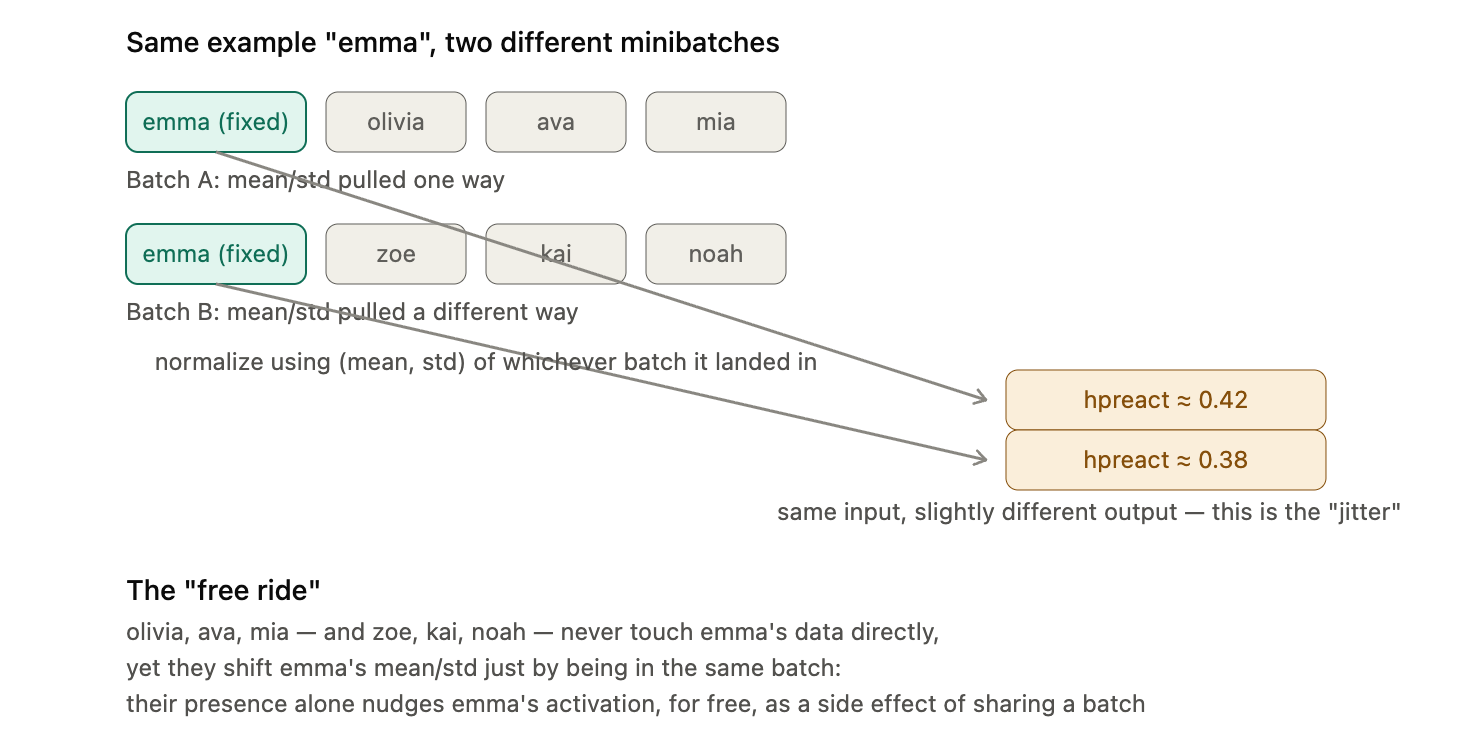

Why the same input produces different outputs

Batch normalization doesn't normalize each example using some fixed, universal statistic — it computes the mean and standard deviation from whatever examples happen to be in the current minibatch, then normalizes every example in that batch using those just-computed numbers:


$$\hat{h}_i = \frac{h_i - \mu_{\text{batch}}}{\sigma_{\text{batch}}}$$

Since μ_batch and σ_batch are computed fresh from whichever 32 (or however many) random examples got sampled together this iteration, the exact same input — say, always the word "emma" — will get divided by a slightly different mean/std depending on which other random names happened to land in the same minibatch. Run "emma" through the network in one minibatch, and it gets normalized one way; run it again in a different minibatch (different companions), and it comes out very slightly different, even though nothing about "emma" itself changed and the weights haven't updated yet.

This is the jitter: a small amount of noise injected into every example's activation, purely as a side effect of who else happens to be sitting in the batch with it that particular step.

Why Karpathy calls it a "free ride"

The phrase captures something slightly funny and non-obvious: the other examples in the batch influence your example's output without ever being directly used in your example's own computation. olivia, ava, and mia don't get multiplied into emma's weights or added to emma's embedding — they never touch emma's data path at all. Yet by simply existing in the same batch, they pull the batch mean and standard deviation in some direction, and that shift gets applied to emma's activation too. They're "along for the ride," exerting influence "for free," without doing any work specific to emma.

Why this jitter is actually useful, not a bug

This might sound like an unwanted quirk, but Karpathy frames it as an accidental regularizer — similar in spirit to techniques like dropout. Because each example's output has a small amount of batch-dependent randomness baked in, the network can't perfectly memorize an exact fixed mapping from input to output; it has to learn representations that are somewhat robust to this noise. This tends to reduce overfitting, the same way other forms of injected randomness during training (like dropout, or data augmentation) do — an unintended but genuinely beneficial side effect of how batch normalization is defined.

The trade-off this creates

This same coupling is also why batch normalization requires special handling at inference/test time — you don't want your model's prediction for a single new input to randomly depend on which other unrelated inputs happen to be batched alongside it in production. This is why training tracks a running average of μ/σ across all batches, and evaluation mode switches to using those fixed running statistics instead of per-batch ones — removing the jitter entirely once you're done training and just want stable, reproducible predictions.


bnmeani = 1/n*hprebn.sum(0, keepdim=True)

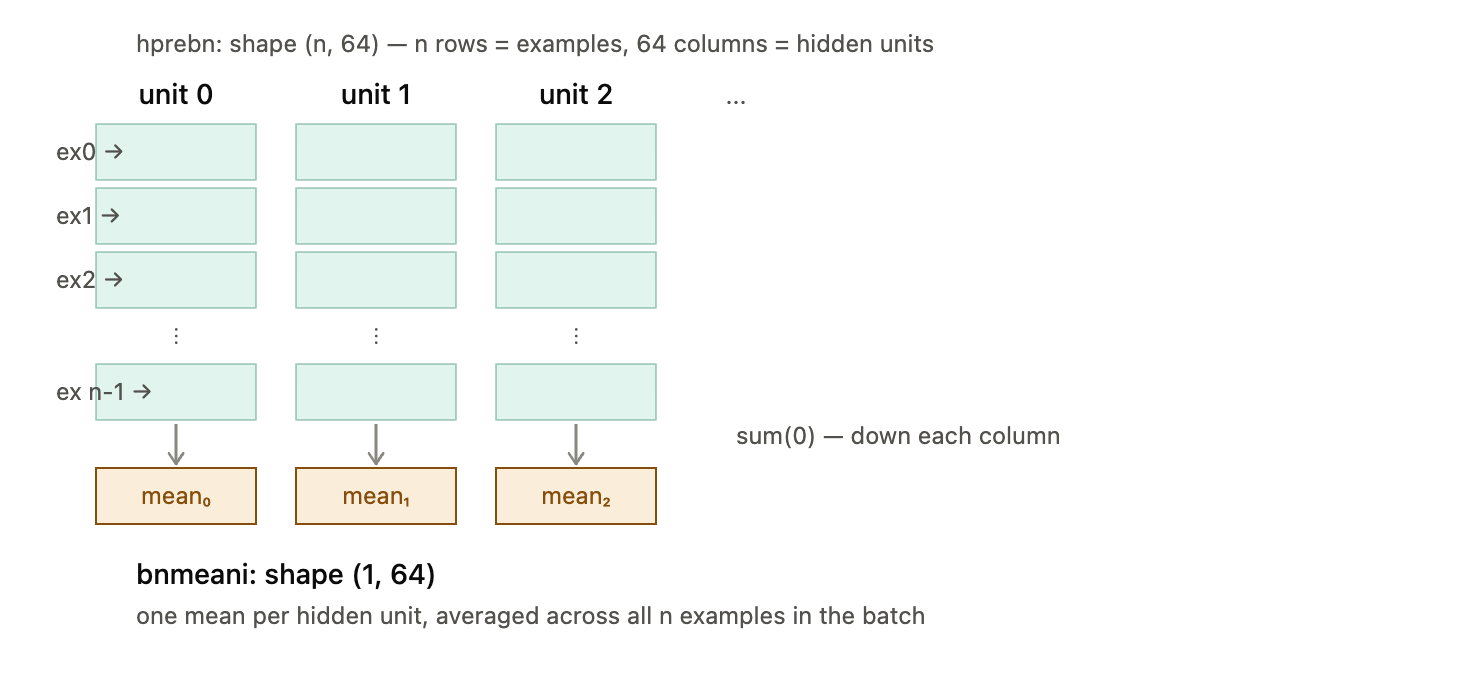

The shape you're working with

hprebn has shape (n, 64):

Rows = individual training examples in the batch (n of them, e.g. 32)
Columns = the 64 hidden units of the network (n_hidden=64)

So entry hprebn[i, j] is "the pre-activation value of hidden unit j, for training example i."

What sum(0, keepdim=True) actually does

In PyTorch's dimension convention, dim=0 refers to the first axis — here, the row axis (the batch/example dimension). .sum(0, ...) collapses dimension 0, meaning it adds up all the values down each column — summing across all n examples, separately for each of the 64 columns.

The result: instead of n rows, you get back just 1 row (that's what keepdim=True preserves — a shape of (1, 64) rather than fully squeezing to (64,)), containing 64 numbers — one total per hidden unit, summed across the entire batch.

So: rows or columns?

To directly answer your question — the summation happens along the rows (it aggregates row-wise, combining values from every row together), but the result is organized per column (one value survives per column/hidden-unit). This is sometimes a source of confusion because "sum along dimension 0" describes which axis gets collapsed/eliminated, not which axis survives.

Why this direction, specifically

Dividing that sum by n (1/n * ...) gives you the average activation of each hidden unit, computed across every example currently in the batch. This is exactly the "batch" in batch normalization: for hidden unit #5, you're asking "across all 32 examples in this batch, what's the typical pre-activation value that unit produces?" — and then every example's unit-5 value gets normalized relative to that shared, per-unit statistic.

Why this is the correct direction (not the other way)

If you instead summed along dimension 1 (across columns, per row), you'd get one mean per example — averaging together the pre-activation values of different, unrelated hidden units within the same example. That would make no statistical sense: hidden unit 0 and hidden unit 47 represent completely different learned features, computed from entirely different weight columns — there's no meaningful reason their raw values should be normalized relative to each other. What does make sense is comparing hidden unit 5's value for example A against hidden unit 5's value for examples B, C, D... — i.e., asking "is this specific feature typically high or low, across the population of examples currently being processed?" That's precisely the per-column (per-hidden-unit) statistic that sum(0) produces, and it's why every hidden unit ends up with its own independent mean and variance, each computed across the batch dimension.



bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5

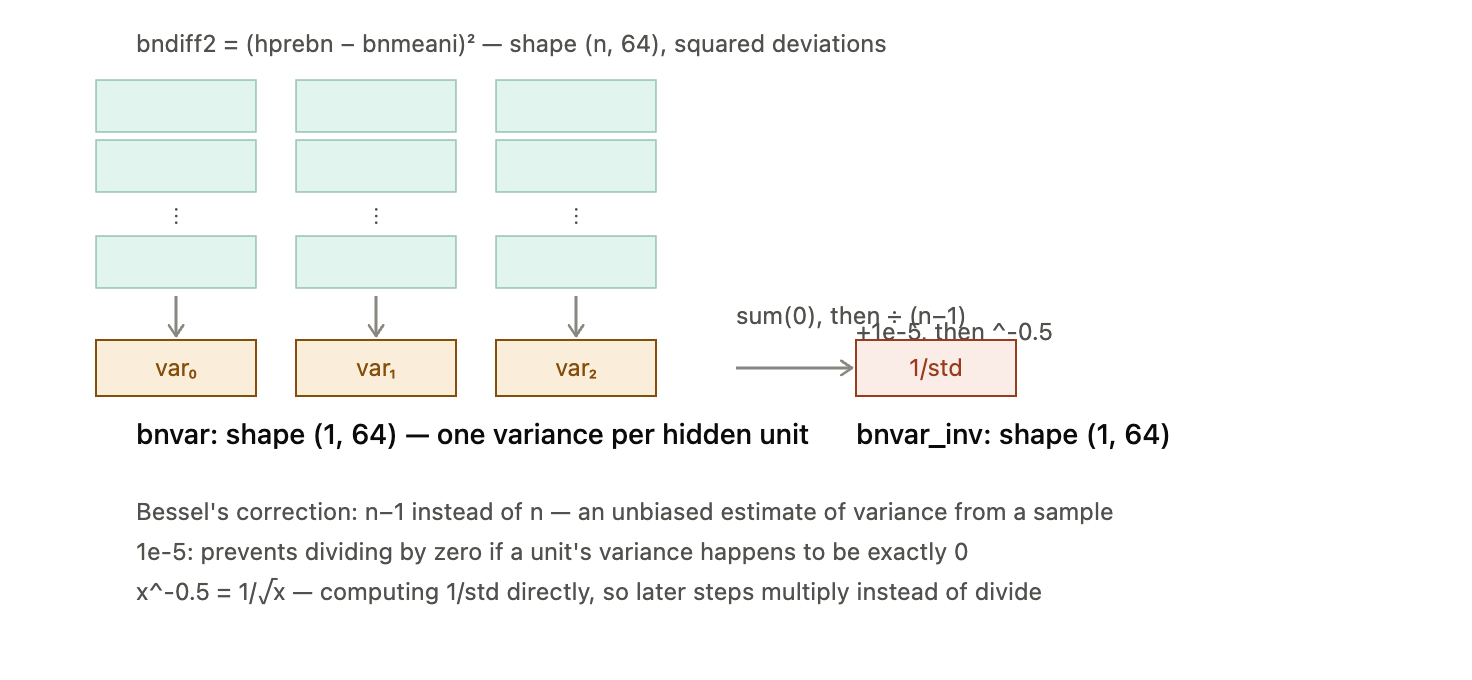

bnvar: variance, per hidden unit

This follows the exact same reduction pattern as bnmeani from the previous question: bndiff2 (the squared deviations from the mean) has shape (n, 64), and .sum(0, keepdim=True) collapses down each column — summing across all n examples in the batch, separately for each of the 64 hidden units. The result, after dividing, is bnvar with shape (1, 64): one variance value per hidden unit, describing how spread out that unit's activations are across the current batch.

Why divide by n-1, not n — Bessel's correction

If you're computing the variance of the entire population you care about, dividing by n is correct. But here, the batch is only a random sample drawn from the full dataset — you're trying to estimate what the "true" variance would be across all possible examples, using just this one batch as evidence. Dividing by n systematically underestimates the true variance when working from a sample (it's a well-known statistical bias), because a sample's own mean is, by construction, the value that minimizes squared deviations for that specific sample — making the sample look slightly less spread out than the true population actually is. Dividing by n-1 instead corrects for this bias, giving a more accurate estimate — this correction is called Bessel's correction, and it's why you'll see n-1 in variance formulas throughout statistics whenever you're estimating from a sample rather than computing from a known, complete population.

bnvar_inv: the inverse standard deviation

bnvar + 1e-5 — adds a tiny constant before anything else happens. This exists purely for numerical safety: if some hidden unit happened to have exactly zero variance in a particular batch (every example producing the identical value for that unit — rare but possible, especially early in training or with unlucky initialization), the next step would involve dividing by zero, producing inf/NaN and silently breaking training. Adding 1e-5 guarantees the denominator is never exactly zero, at a cost so small it doesn't meaningfully affect normal, well-behaved variance values.

** -0.5 — raising to the power of -0.5 is mathematically identical to 1 / sqrt(x). So bnvar_inv is literally one over the standard deviation — computed in a single step, directly as its own tensor, rather than first computing std = sqrt(bnvar) and later writing bndiff / std elsewhere in the code.

Why compute the reciprocal directly, instead of dividing later

This connects to the same numerical-precision concern from your counts_sum_inv question a few turns back: multiplying by a precomputed reciprocal (bndiff * bnvar_inv) versus dividing (bndiff / std) are mathematically equivalent, but can produce slightly different floating-point rounding. Since this whole exercise is about getting manually-derived gradients to match PyTorch's autograd bit-for-bit (via the cmp() function's exact-equality check), Karpathy consistently chooses whichever formulation makes the hand-derived backward pass line up precisely — multiplication by a precomputed inverse, rather than a fresh division, tends to make that exact match achievable.


logit_maxes = logits.max(1, keepdim=True).values

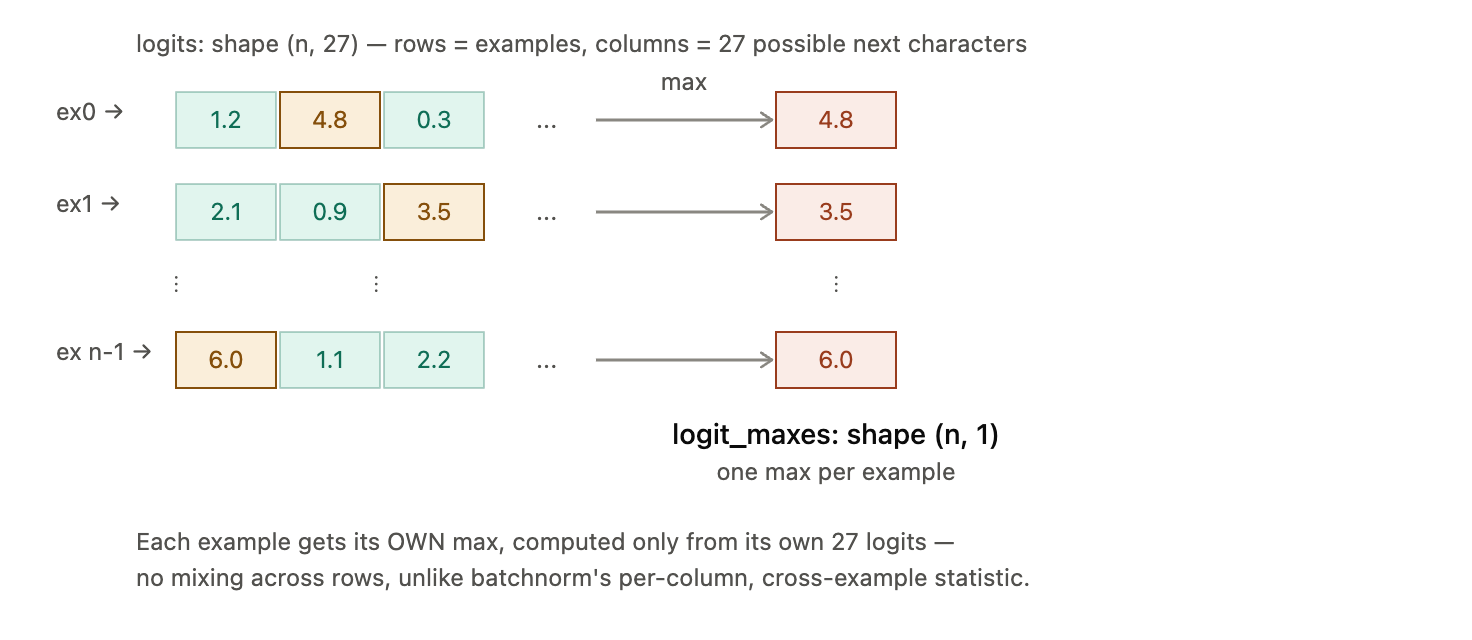

The shape you're working with

logits has shape (n, 27):

Rows = individual examples in the batch
Columns = the 27 possible next characters, each with its own raw score
What max(1, keepdim=True) does

dim=1 refers to the second axis — the column axis (the 27-character/vocabulary dimension). .max(1, ...) collapses across the columns, for each row separately, finding the single largest value among that row's 27 logits. keepdim=True keeps the result shaped (n, 1) rather than squeezing to (n,), so it can broadcast cleanly against the original (n, 27) tensor in the next line (norm_logits = logits - logit_maxes). .values is needed because torch.max with a dimension argument returns both the max values and their indices as a named tuple — .values pulls out just the numbers, discarding the index information you don't need here.

Why along the rows (per example), not the columns (per batch)

This is the mirror image of your batchnorm question, and the direction is opposite for a very deliberate reason.

In batch normalization, you wanted cross-example coupling — the whole point was computing a statistic (mean/variance) shared across the batch, per hidden unit. Here, it's the opposite: each example's softmax must be computed entirely independently of every other example. Example 0's probability distribution over the next character has nothing to do with example 1's — they're unrelated predictions for unrelated contexts. Mixing them would be meaningless, the same way it would've been meaningless to average hidden-unit values across different columns in the batchnorm case.

Concretely: subtracting the max logit from every logit in that same row is a numerical-stability trick — it doesn't change the final softmax probabilities at all (since it's the same shift applied uniformly within that row, and the normalization step later cancels it out), but it prevents exp() from overflowing on a large raw logit value before you even get to counts_sum. For this trick to work correctly, you need that specific example's own maximum — subtracting some other example's max (or a max computed across the whole batch) wouldn't reliably bring this row's largest value down near zero, and could still let some other row overflow.

The general pattern worth remembering

Whenever you see a reduction like .sum(dim) or .max(dim), ask: "which axis is being collapsed, and does that match what should logically be grouped together?" Batchnorm's dim=0 reduction groups across examples, within one feature — appropriate because that's a genuine population statistic you want to share. This softmax's dim=1 reduction groups across the vocabulary, within one example — appropriate because each example's prediction is a self-contained probability distribution that must never leak into, or draw from, any other example's computation.



loss = -logprobs[range(n), Yb].mean()

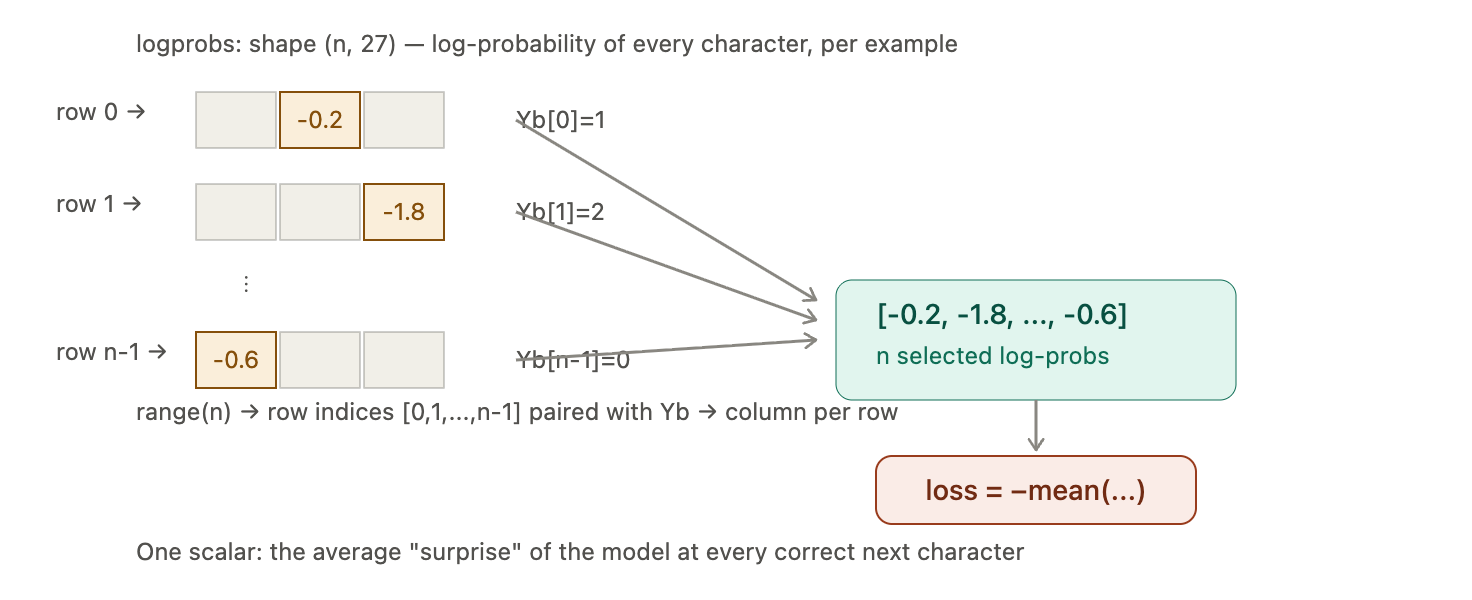

This is the exact same paired-indexing pattern from your earlier probs[torch.arange(32), Y] question — just applied to logprobs instead of probs, and using n as the general batch size rather than a hardcoded 32.

Breaking it down

logprobs has shape (n, 27) — the natural log of every predicted probability, for every example, across all 27 possible next characters. This came from logprobs = probs.log() in your forward pass.

range(n) generates [0, 1, 2, ..., n-1] — simply "the row number of each example," in order (functionally identical to torch.arange(n), just using Python's built-in range instead of a PyTorch tensor — both work fine for this kind of indexing).

logprobs[range(n), Yb] pairs the row indices with Yb (the correct target character for each example) position-by-position: row 0 paired with Yb[0], row 1 paired with Yb[1], and so on. This selects exactly one number per row — specifically, the log-probability the model assigned to the actual correct next character for that example. Everything else in each row (the log-probabilities of the 26 wrong characters) gets ignored entirely; only the one correct-answer column survives, per row.

Why -... and .mean()

Negation: logprobs values are always negative or zero (since probabilities are between 0 and 1, and log of a number in that range is ≤ 0). A perfect prediction (probability = 1) gives log(1) = 0; a terrible prediction (probability near 0) gives a large negative log-probability. Negating flips this so that better predictions produce a lower (better) loss, and worse predictions produce a higher (worse) loss — matching the usual convention that "loss" should be something you're trying to minimize toward zero, not a negative number.

.mean() collapses the n individual per-example losses into a single scalar, averaging the model's "surprise" across the entire batch — exactly what loss.backward() needs to compute one unified gradient signal for every parameter in the network.

Connecting back to your earlier questions

This line is functionally identical to your very first cross-entropy question (-probs[torch.arange(32), Y].log().mean()) — the only difference is that here, the .log() was already applied earlier as its own separate atomic step (logprobs = probs.log()), rather than being chained at the end in one line. This is precisely why: breaking .log() out into its own named intermediate tensor is what lets you compute a manual gradient for it individually and check it with cmp(), rather than lumping the log and the mean together into a single derivative to work out by hand.

Each row is neither a whole word nor a bare character — it's one single (context → next character) prediction, i.e., one specific sliding-window position that occurred somewhere in your dataset.

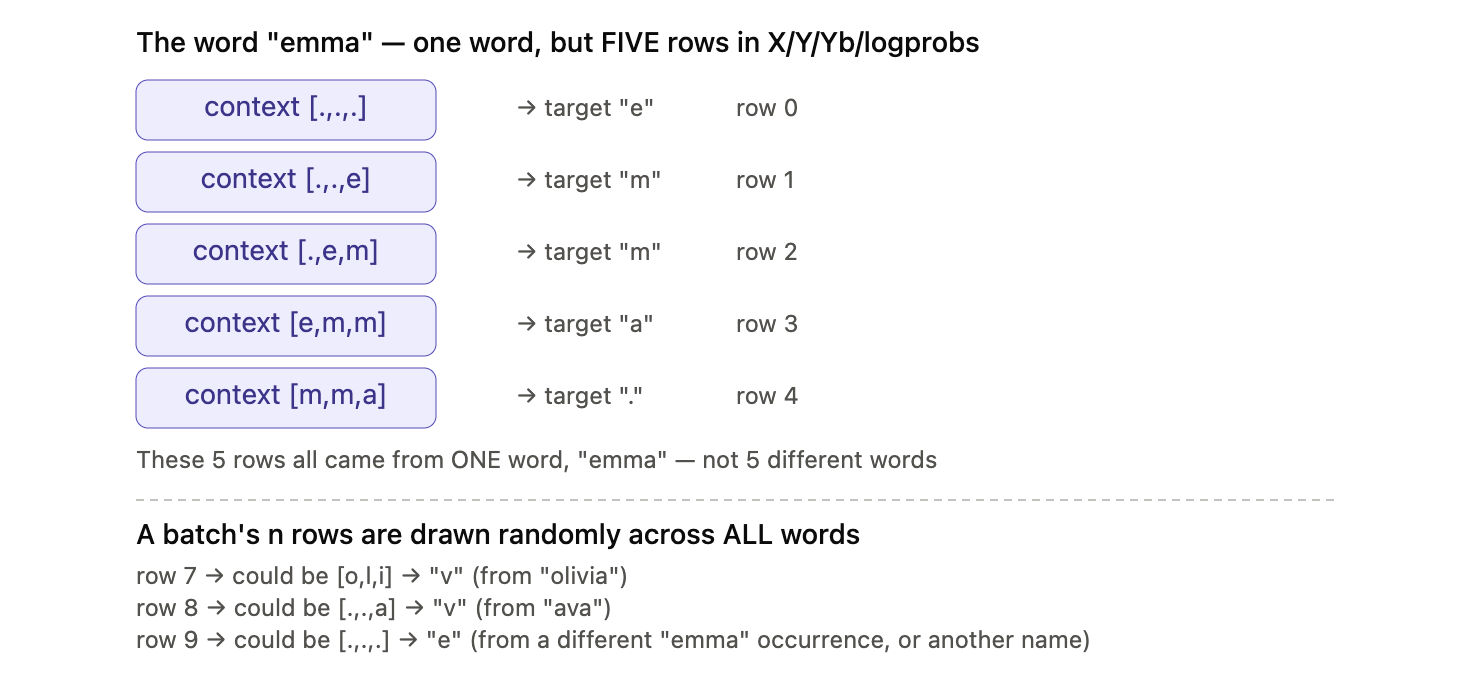

Direct answer: neither a whole word nor a single character in isolation

Each row is one specific prediction task: a fixed 3-character context, paired with the one character that actually came next at that exact position in the original data. It's a snapshot of "given these 3 previous characters, what should come next," taken from one particular spot in one particular word.

Why a single word produces multiple rows

Recall the build_dataset sliding window from several questions back: for a 4-letter word like emma, the inner loop runs 5 times (once for each of the 4 real characters, plus the appended . end token). Each of those 5 iterations appends one row to X and one row to Y. So the single word emma doesn't become one row — it becomes five separate rows, each capturing a different position within that same word as it unfolds character by character.

What this means for logprobs, Yb, and the loss

By the time you're computing loss = -logprobs[range(n), Yb].mean(), you're working with a batch of n such rows — and critically, these rows are not all from the same word. Because of torch.randint(0, Xtr.shape[0], (batch_size,)) from your minibatch-construction question earlier, each row in a batch is independently, randomly sampled from the entire pool of sliding-window examples across all 32,033 words combined. So row 0 of your batch might be a position from emma, row 1 might be from olivia, row 2 might be another position from a totally different name, and so on — the batch is a random mixture of context-prediction snippets pulled from anywhere in the dataset, not a coherent group of related examples.

Why this matters for intuition

This is worth internalizing because it explains why n (your batch size, e.g. 32) is much smaller than 32,033 (the number of words) but can still be much larger than that if you count total rows: the real number of training examples (X.shape[0]) is the sum of len(word)+1 across every single word — likely several hundred thousand rows in total, since each word contributes multiple rows. The model never "sees a whole word" as a single unit during training — it only ever sees isolated (context, next-character) snippets, and it's only through repeated exposure to many such snippets, across many words, that it gradually learns the patterns that make its generated output look name-like when you later sample character-by-character from it.

the batch's content is different every single training iteration. There's no fixed, unchanging "batch 1, batch 2, batch 3..." — instead, a brand-new random selection of 32 rows gets drawn fresh at the start of every step.

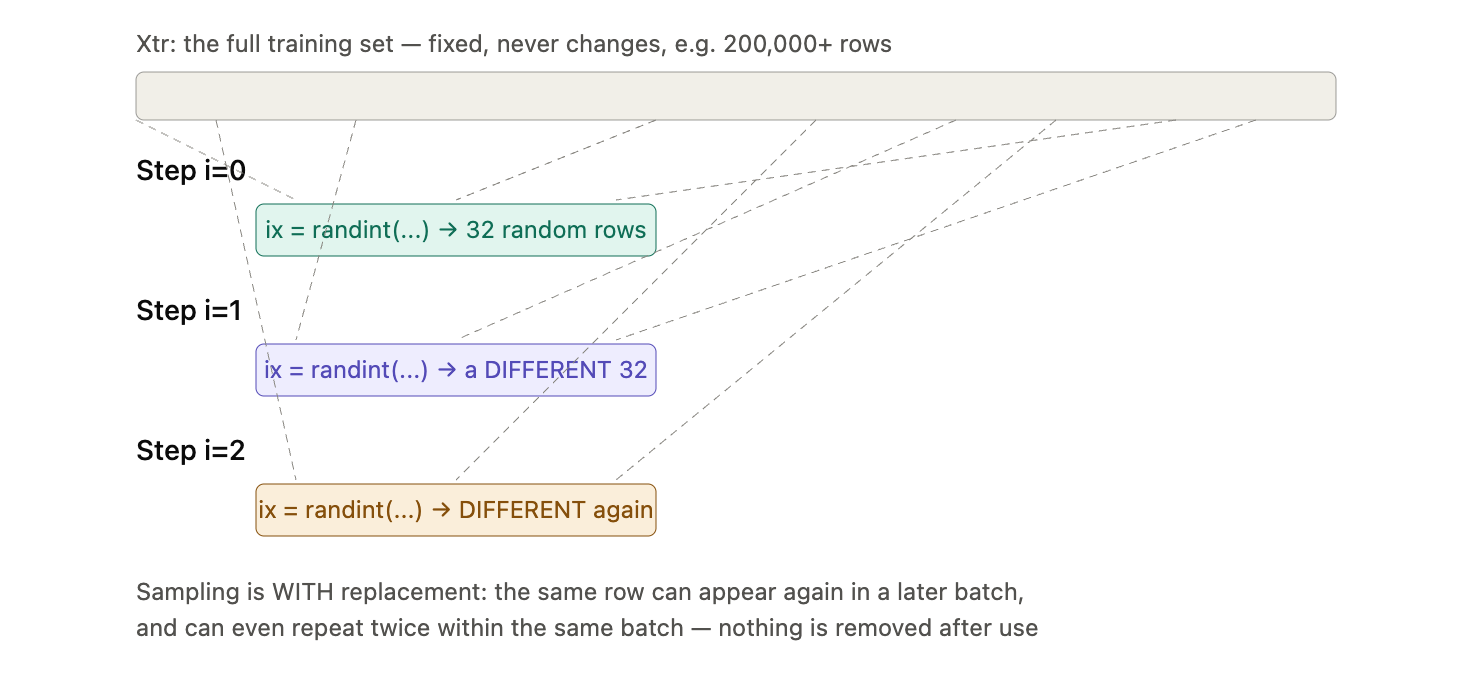

Where the dynamic behavior comes from

Look at where ix = torch.randint(0, Xtr.shape[0], (32,)) sits — it's inside the training loop, executed fresh on every single pass through for i in range(max_steps). Each call to torch.randint generates a brand-new set of 32 random integers, completely independent of what the previous call generated. So:

Xtr itself never changes — it's the fixed, complete training set, built once by build_dataset and never modified afterward.
ix changes every iteration — a fresh random draw each time, meaning Xb = Xtr[ix] and Yb = Ytr[ix] pull out a different 32 rows on step 0, step 1, step 2, and so on, all the way through 200,000 steps.
"With replacement" — an important detail

torch.randint samples with replacement, meaning the same row index can be picked again — either later in training (row 47 might show up in batch #3, then again in batch #8,192) or even within the same batch (in principle, row 47 could theoretically be drawn twice in the same call, though unlikely with a large dataset and small batch size). This is different from some other minibatching schemes that shuffle the entire dataset once per epoch and walk through it in non-overlapping chunks, guaranteeing every row is seen exactly once before repeating. Karpathy's approach here is simpler: pure random sampling every step, no explicit epoch bookkeeping — over enough steps, this still achieves the same effect of broad, repeated coverage, as your earlier math about 200,000 × 32 visits worked out.

Why this matters for what "the batch" means

There isn't a meaningful, fixed thing called "the batch" that persists across training — it's more accurate to think of "a batch" as a temporary, one-off snapshot, freshly constructed at the start of each iteration, used immediately for one forward pass, one backward pass, one parameter update, and then discarded. The variables Xb/Yb get completely overwritten with new content on the very next loop iteration — nothing about the previous batch's specific rows persists or accumulates anywhere.

Why this randomness is actually desirable, not incidental

This constant reshuffling is what makes minibatch gradient descent work well as an optimization strategy: each step's gradient is a noisy, quick estimate based on whatever random subset it happened to see, but because the subset itself changes every time, that noise doesn't systematically bias training toward any particular slice of the data — over many steps, the cumulative effect averages out to behave much like training on the full dataset, while being dramatically cheaper to compute at each individual step.